# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Adrià Valmaña Perez
* Username: avalmana
* Student number: s6217338
* Group (AS1, etc.): AS5

-----

In [ ]:
import matplotlib.pyplot as plt
from jsonschema.benchmarks.contains import size

totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

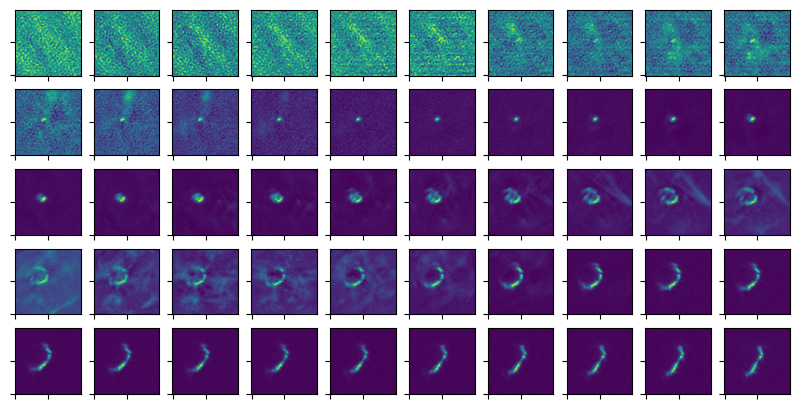

In [688]:
from astropy.io import fits
import matplotlib.pyplot as plt

hdul = fits.open('ngc6946.fits')
data = hdul[0].data

fig, axs = plt.subplots(5, 10,
                        sharex=True,
                        sharey=True)

Z = range(1, 101, 2)
z = 0
for i in range(5):
    for j in range(10):
        axs[i, j].imshow(data[z, :, :],
                         origin='lower',)
        axs[i,j].set_xticklabels([])
        axs[i,j].set_yticklabels([])
        z += 1

fig.set_figheight(5)
fig.set_figwidth(10)
plt.show()

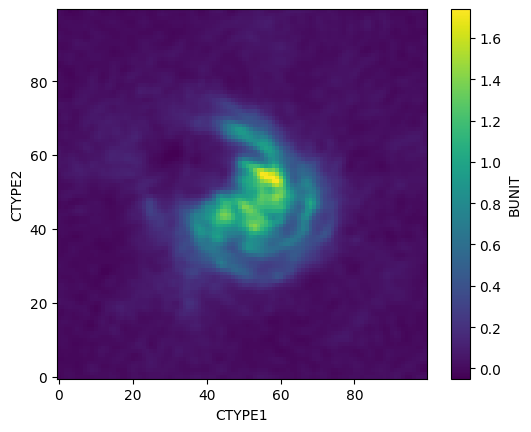

In [689]:
plt.imshow(sum(data[31:101, :, :]),
           origin='lower',)
plt.xlabel('CTYPE1')
plt.ylabel('CTYPE2')
plt.colorbar(label = 'BUNIT')
plt.show()

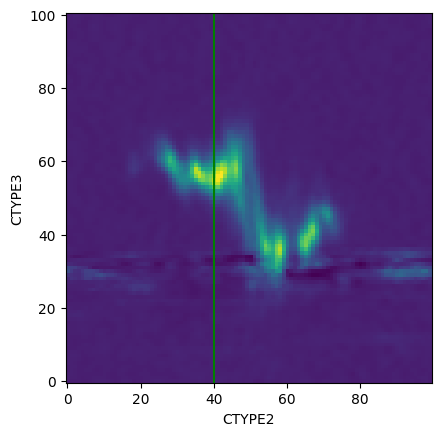

In [690]:
plt.imshow(data[:, :, 50],
          origin = 'lower')
plt.axvline(40, color='g')
plt.xlabel('CTYPE2')
plt.ylabel('CTYPE3')
plt.show()

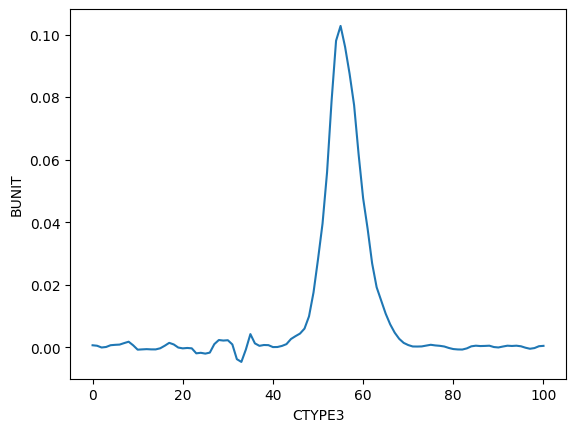

In [691]:
plt.plot(data[:, 40, 50])
plt.xlabel('CTYPE3')
plt.ylabel('BUNIT')
plt.show()
# We can see how the heigh of this graph corresponds to the colour of the previous image along the plotted line
hdul.close()

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

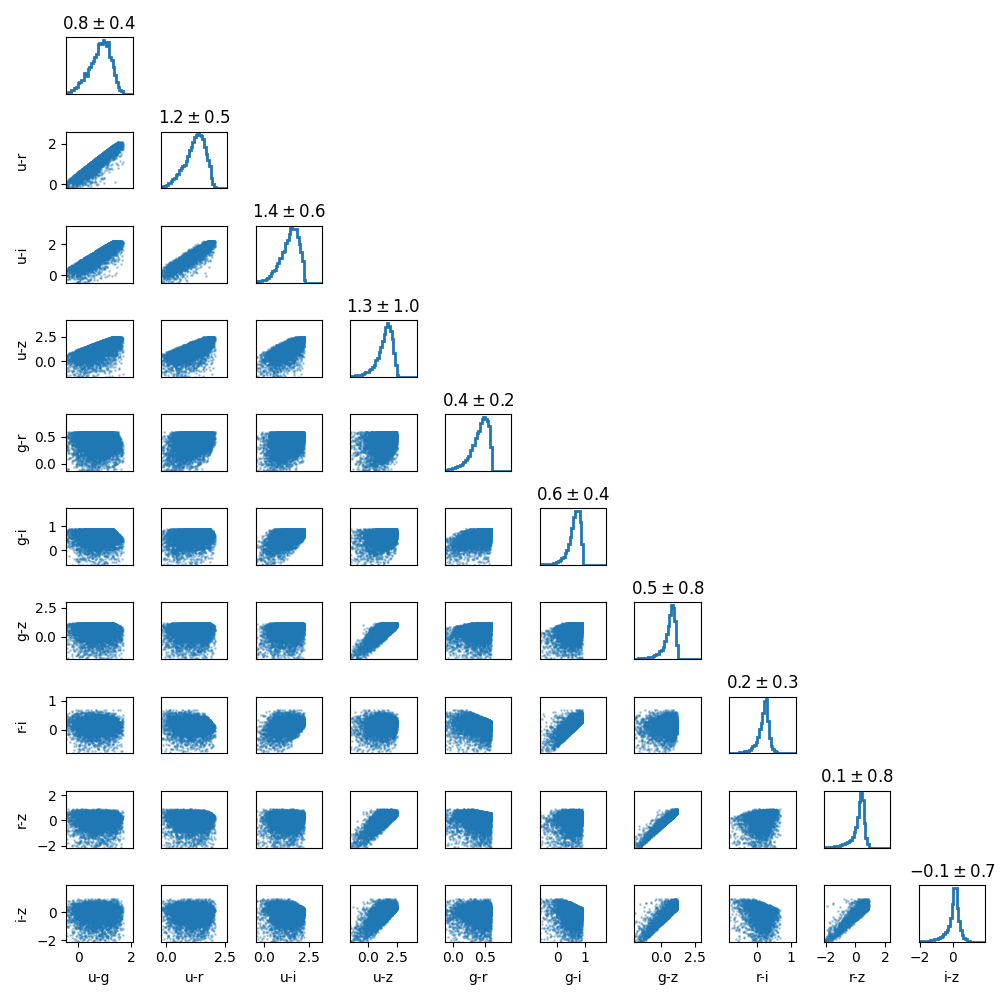
   
**Plot and answer**:

In [551]:
import pandas as pd
from astropy.table import Table

dat = Table.read('SDSS_DR17_galaxies.fits', format='fits')
df = dat.to_pandas()
df_filtered = df[df >= 0].dropna()
df_filtered

,ObjID,u,g,r,i,z
0,1237667429572346493,22.133240,22.190250,21.788059,21.355808,21.630119
1,1237665225699688707,21.623161,21.394985,20.979010,20.807341,21.209600
2,1237661849859391812,21.970703,21.247322,20.650488,20.399561,20.187206
3,1237655464310014355,21.850883,21.075569,20.600910,20.281101,20.171160
4,1237668332564316684,22.198875,21.121441,20.892130,20.848957,20.391762
...,...,...,...,...,...,...
9995,1237660959178294166,22.973991,22.382448,21.856314,21.788813,21.348269
9996,1237651539241009608,21.098238,20.990377,20.525063,20.709217,20.165453
9997,1237678889598320905,23.743755,22.205927,21.988956,22.066080,21.879768
9998,1237678887982268834,22.025555,21.216351,20.670090,20.539196,20.544683


Color columns used for plotting: ['u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z']


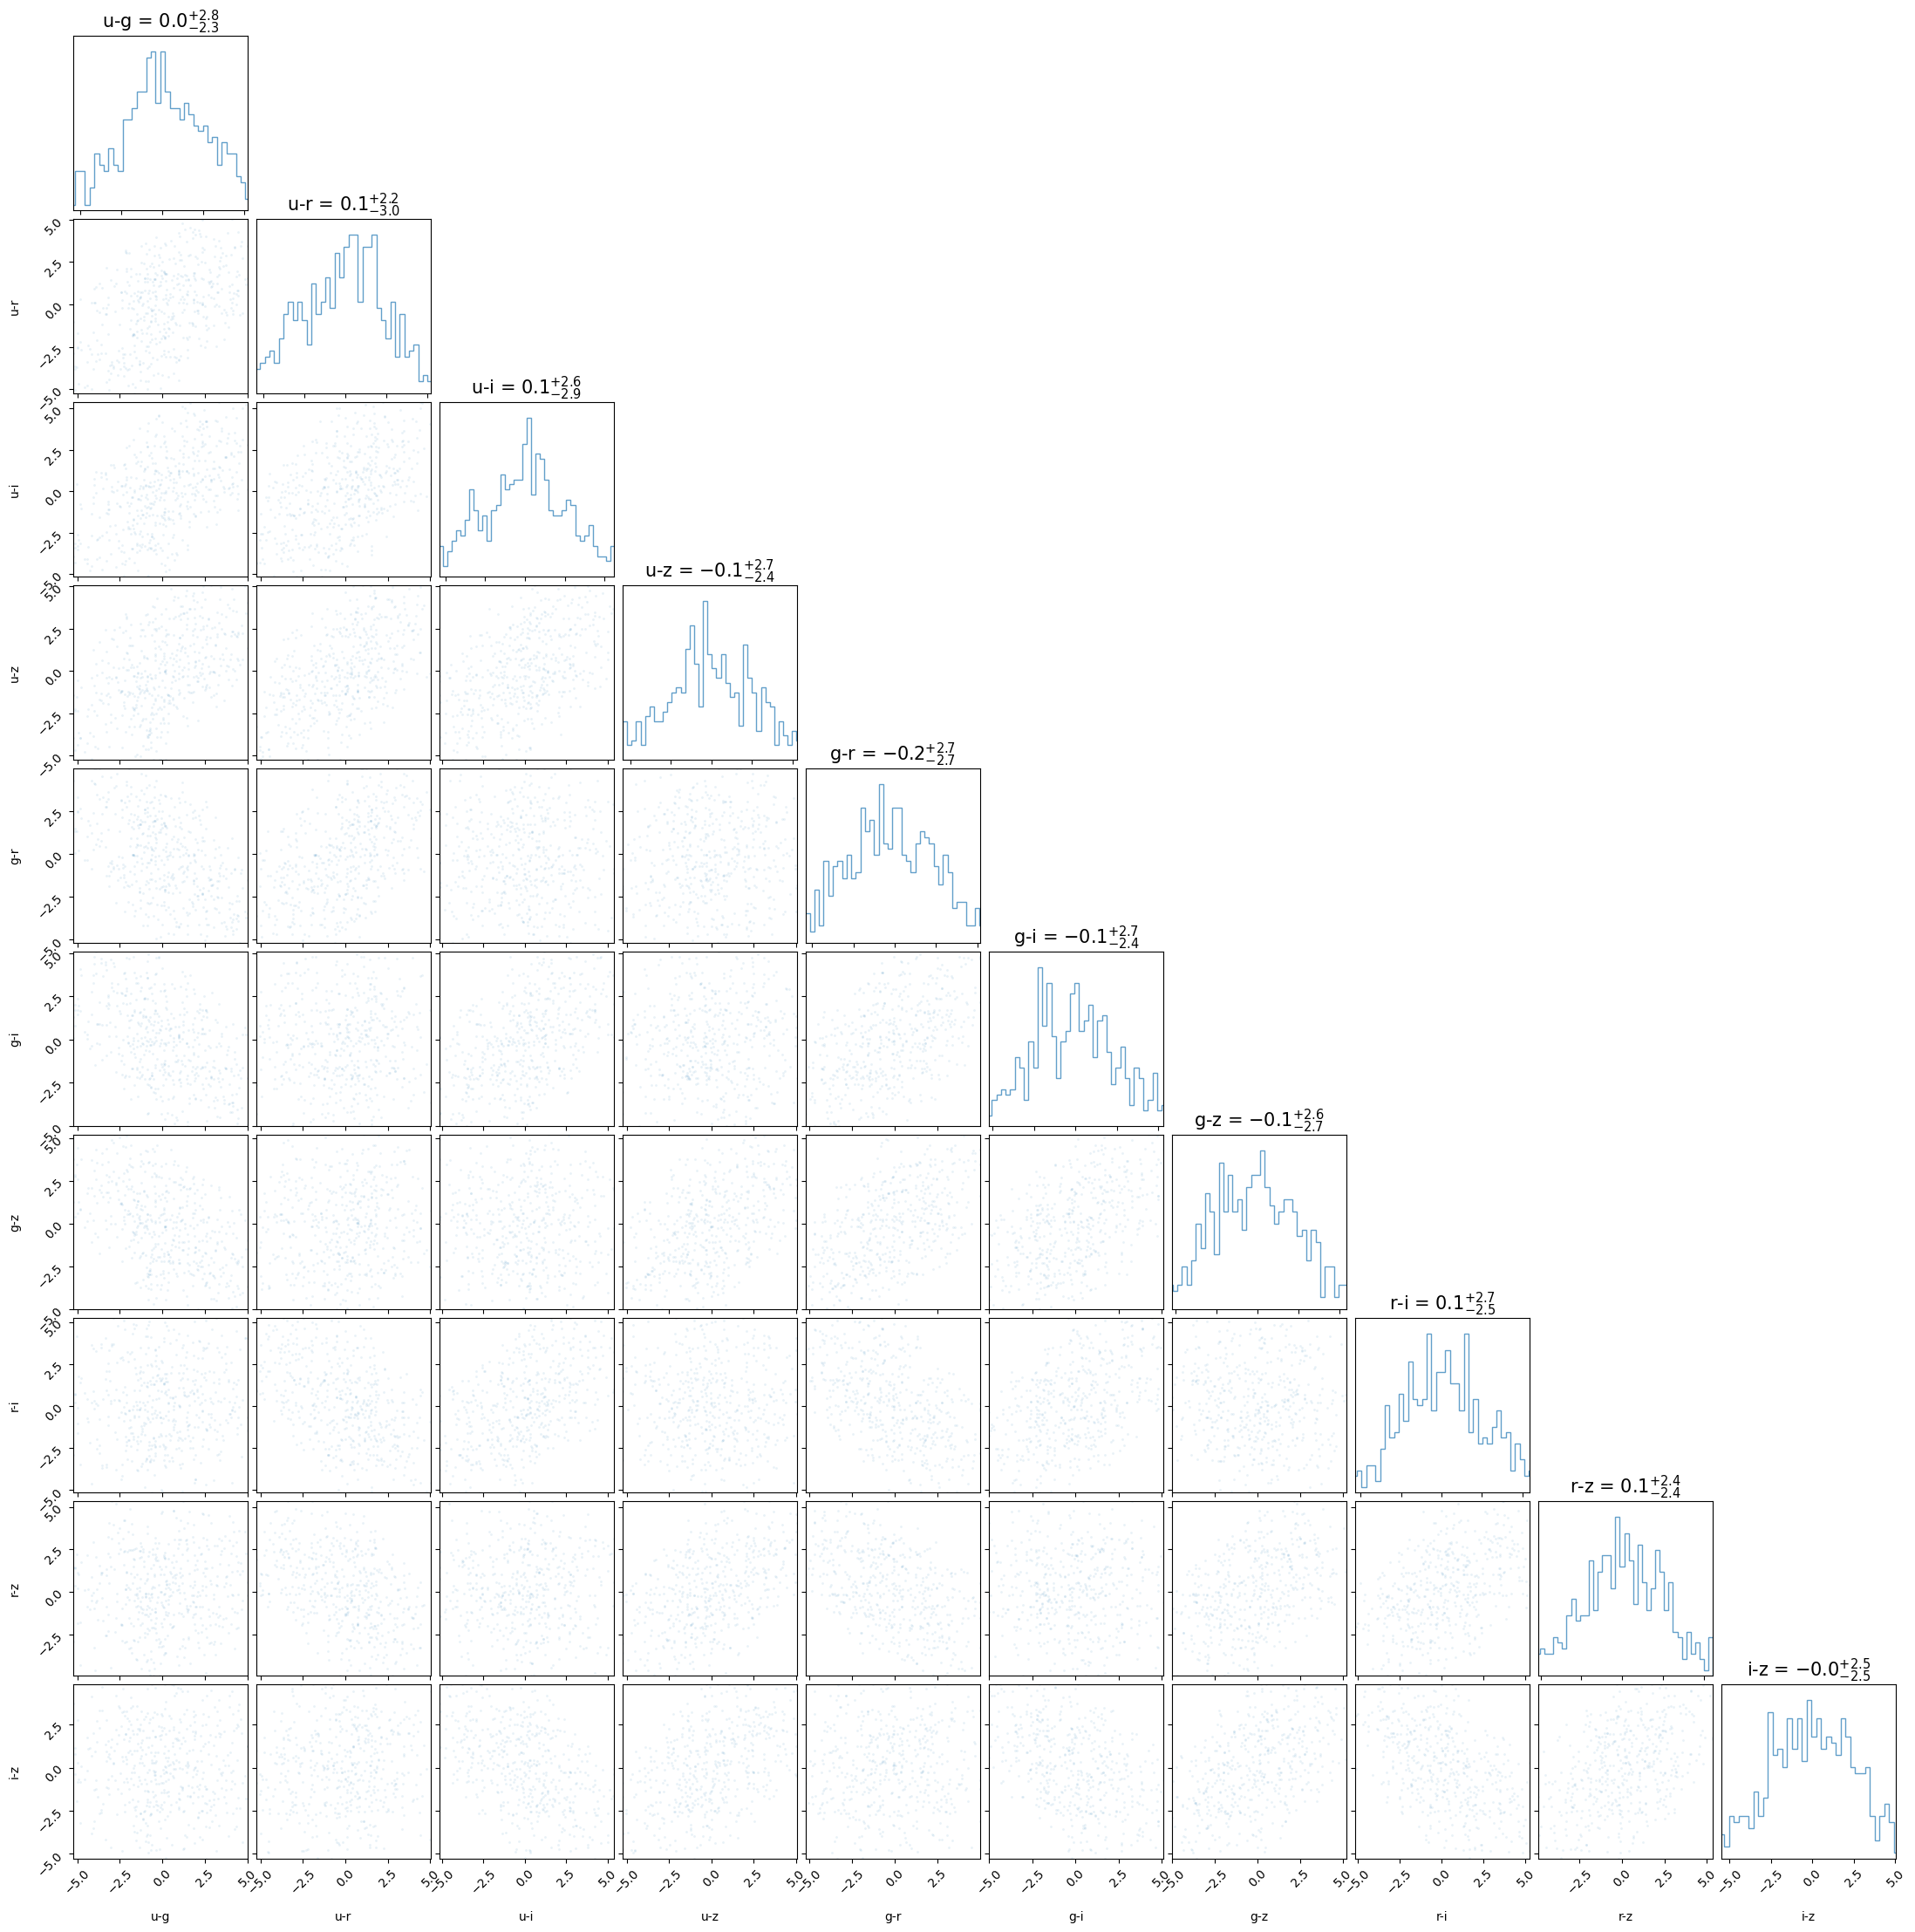

In [699]:
import pandas as pd
import numpy as np
import corner
import matplotlib.pyplot as plt
from itertools import combinations

bands = ['u', 'g', 'r', 'i', 'z']
color_pairs = list(combinations(bands, 2))  # all posterior pairs

for c1, c2 in color_pairs:
    df_filtered[f'{c1}-{c2}'] = df_filtered[c1] - df_filtered[c2]

df.columns = df.columns.str.strip().str.lower()

bands = [b for b in ['u', 'g', 'r', 'i', 'z'] if b in df.columns]

for b1, b2 in combinations(bands, 2):
    df[f'{b1}-{b2}'] = df[b1] - df[b2]

color_cols = [col for col in df.columns if '-' in col and df[col].std() > 0]
data = df[color_cols].dropna().values

print("Color columns used for plotting:", color_cols)

figure = corner.corner(
    data,
    labels=color_cols,
    show_titles=True,
    title_fmt=".1f",
    title_kwargs={"fontsize": 15},
    title_quantiles=[0.16, 0.5, 0.84],
    plot_density=False,
    plot_datapoints=True,
    plot_contours=False,
    fill_contours=False,
    bins=40,   # set histogram bins globally here
    hist_kwargs={'alpha':0.7, 'color':'C0'},  # removed 'bins'
    scatter_kwargs={'s': 1000, 'alpha': 1},
    color='tab:blue'
)

axes = figure.get_axes()
n = len(color_cols)

for i in range(n):
    for j in range(i+1):
        ax = axes[i*n + j]

        if i == j:
            vals = df[color_cols[i]].dropna().values
            p1, p99 = np.percentile(vals, [1, 99])
            pad = 0.02 * (p99 - p1)
            ax.set_xlim(p1 - pad, p99 + pad)
        else:
            x = df[color_cols[j]].dropna().values
            y = df[color_cols[i]].dropna().values
            x1, x99 = np.percentile(x, [1, 99])
            y1, y99 = np.percentile(y, [1, 99])
            ax.set_xlim(x1, x99)
            ax.set_ylim(y1, y99)

plt.show()

In [ ]:
p# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

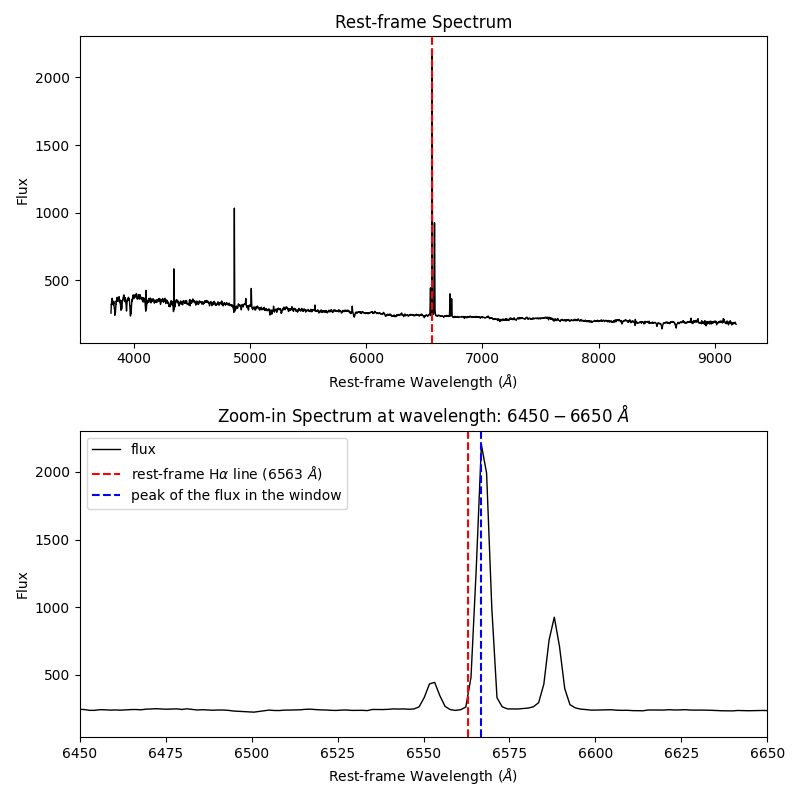

In [585]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
import astropy.units as u

ra = 40.6696
dec = -0.0133
pos = coords.SkyCoord(ra, dec, unit='deg', frame='icrs')

xid = SDSS.query_region(pos, spectro=True, radius=10*u.arcsec)
sd = SDSS.get_spectra_async(matches=xid)
sp = sd[0].get_fits()

TimeoutError: Query timed out, time elapsed 60s

In [651]:
hdul = fits.open('spec-1511-52946-0351.fits')
data = hdul[1].data

flux = data['flux']
loglam = data['loglam']
wavelength = 10**loglam
restframe_wavelength = wavelength / (1 + 0.0038)

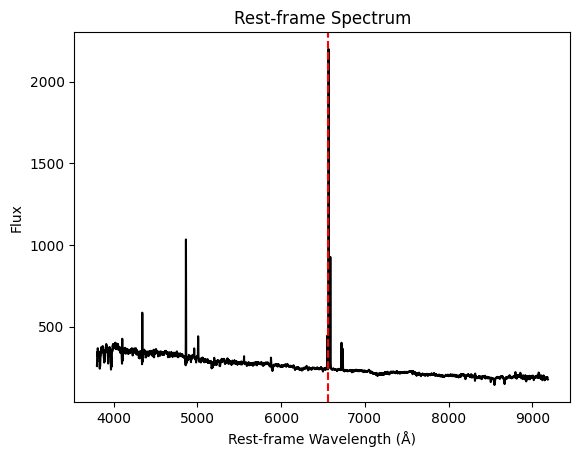

In [664]:
plt.figure()
plt.plot(restframe_wavelength, flux,
         color='k')
plt.xlabel('Rest-frame Wavelength (Å)')
plt.ylabel('Flux')
plt.axvline(x=6563,
            color='r',
            linestyle='--')
plt.title('Rest-frame Spectrum')
plt.show()

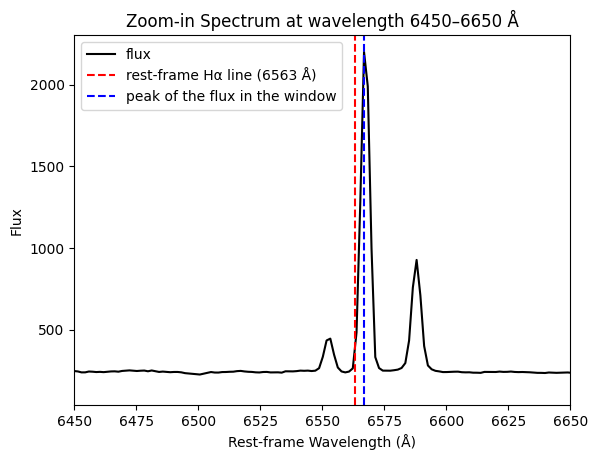

In [677]:
plt.figure()
plt.plot(restframe_wavelength, flux,
         color='k',
         label='flux')
plt.xlim(6450, 6650)
plt.xlabel('Rest-frame Wavelength (Å)')
plt.ylabel('Flux')
plt.title('Zoom-in Spectrum at wavelength 6450–6650 Å')
plt.axvline(x=6563,
            color='r',
            linestyle='--',
            label='rest-frame Hα line (6563 Å)')
plt.axvline(x=restframe_wavelength[np.where(flux == flux.max())],
            color='b',
            linestyle='--',
            label='peak of the flux in the window')
plt.legend(loc='upper left')
plt.show()

In [698]:
v = 3e8 * (( 6566.785 - 6563) / 6566.785 )
print(f'v = {v:g} m/s')

v = 172916 m/s


We know this velocity is radially away from us, since it is red-shifted. This could be caused due to either the galaxy moving away from us, the universe expanding between us, or a cloud of dust in the path of the light.

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

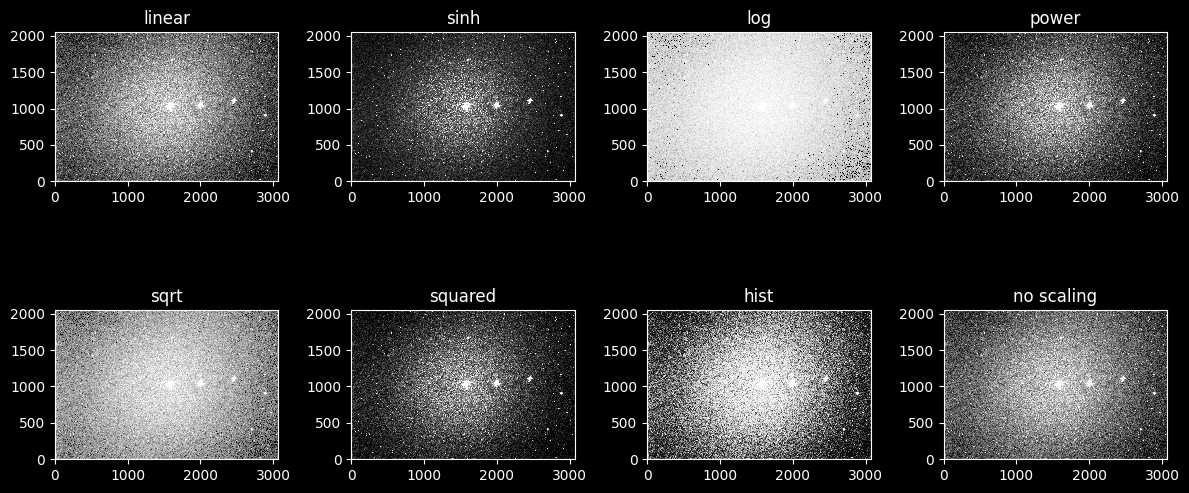

In [415]:
from astropy.io import fits
from astropy.visualization import ImageNormalize
from astropy.visualization import (SinhStretch, AsymmetricPercentileInterval, LinearStretch,
                                   LogStretch, PowerStretch, SqrtStretch, SquaredStretch,
                                   HistEqStretch, ZScaleInterval)
import matplotlib.pyplot as plt

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    '''Extended version of plt.imshow() with normalization and stretch options'''
    if zscale:
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)

    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch()
    elif scale == 'sinh':
        stretch = SinhStretch()
    elif scale == 'log':
        stretch = LogStretch()
    elif scale == 'power':
        stretch = PowerStretch(power)
    elif scale == 'sqrt':
        stretch = SqrtStretch()
    elif scale == 'squared':
        stretch = SquaredStretch()
    elif scale == 'hist':
        stretch = HistEqStretch(data)
        vmin, vmax = data.min(), data.max()
    else:
        raise ValueError(f"Unknown scale: {scale}")

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

hdul = fits.open('20210422_Li_.00000066.FIT')
data = hdul[0].data

scales = ['linear', 'sinh', 'log', 'power', 'sqrt', 'squared', 'hist']
mosaic_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

fig, axs = plt.subplot_mosaic([['A','B','C','D'], ['E','F','G','H']], figsize=(12,6))
for scale, label in zip(scales, mosaic_labels):
    ax = axs[label]
    imdisplay(data,
              ax,
              scale=scale)
    ax.set_title(scale)

ax = axs['H']
imdisplay(data, ax)
ax.set_title('no scaling')

plt.tight_layout()
plt.show()


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [729]:
filepaths = /net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/

fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    count += 1
    hdulist.close()
show()

SyntaxError: invalid syntax (2454185377.py, line 1)

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")